# Microscopic Image Reconstruction via Deep Learning (Autoencoder plus GAN plus Multi-Task Model)

## Project Description:
The goal of this code is to create a tool to increase the clarity of microscopy images of nuclei cells. The Autoencoder will be used for removing noise from the images being produced and recreate a version of the image without that original noise. The GAN part of the program will help to generate a clearer, more realistic version of reconstructed images. The multi-task prediction feature of this model will allow for further analysis of such images for biomedical purposes.

## Code Description:

1) Dataset (Preparing Data):
- Extracting images of nuclei cells from the nu_data dataset.
- All images will be resized to 256 x 256 in dimensions.

2) Dataset Class:
- Images will be loaded from folders.
- The mask images will be combined into one mask.
- Different structures of dataset folders will be supported.

3) Autoencoder:
- The input images will be compressed (smaller in size).
- Noise will be removed from the images.
- Cleaner images of nucleus cells (reconstructed) will be produced.

4) GAN:
(Only found in the older version of the model)
- Generator will improve upon the reconstructed images created by the Autoencoder.
- The Discriminator will determine if an image is a real (using the training dataset) or an artificial (the image produced by the Autoencoder) image.
- The GAN will improve the quality of the images being generated.

5) Multi-task Model:
(This is a feature new to the model)
- Morphology predictions.
- NanoBio property predictions.
- Screening score generation.

6) Training:
- The images will be run through the Autoencoder.
- In the older model, the generator will improve upon the Autoencoder's output images.
- The Discriminator will provide feedback as to whether the images are real or artificial.
- Models will learn using an optimizer and loss function.

7) Evaluation Metrics:
- Peak Signal to Noise Ratio (PSNR) will evaluate reconstruction quality.
- Structural Similarity Index Measure (SSIM) will evaluate structural similarity between the original and output images.

## The table below summarizes the features of both the current and New versions and highlights specific changes made.

- Encoder: the old model has an encoder that is a basic CNN; the new model has ResNet18 (a much better feature extractor than what the old model has)

- GAN: the old model uses a GAN, while the new model does not.

- Multi-task Prediction: the old model does not make use of this capability, but it is available in the new model.

- Image Reconstruction: image reconstruction is available in both the old and the new version.

- Morphology Prediction: morphology prediction is not possible with the old model, but is now available with the new model.

- NanoBio Prediction: nano bio prediction was not possible with the old model, but is now available with the new model.

- Screening Score: screening score is not possible with the old model but is available in the new model.

- Architecture Level: while the previous version was a medium-level model, now we have an advanced level model.



## INSTALL & IMPORTS

### Install Dependencies

In [ ]:
!pip install tensorflow opencv-python matplotlib scikit-image scikit-learn

In [ ]:
!pip install torch torchvision torchaudio
!pip install scikit-learn matplotlib seaborn pandas opencv-python scikit-image shap

### Import Libraries

In [ ]:
import os
import cv2
import time
import shap
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error
)

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import os
import cv2
import time
import torch
import shap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc

## Dataset

In [ ]:
!git clone https://github.com/Charith003/nu_data.git

Cloning into 'nu_data'...
remote: Enumerating objects: 8441, done.
remote: Total 8441 (delta 0), reused 0 (delta 0), pack-reused 8441 (from 1)
Receiving objects: 100% (8441/8441), 199.34 MiB | 16.85 MiB/s, done.
Resolving deltas: 100% (433/433), done.
Updating files: 100% (8427/8427), done.


In [ ]:
!ls nu_data

2009_ISBI_2DNuclei  BBBC020			stage_1_test
BBBC006		    cluster_nuclei		stage_1_train
BBBC007		    color_wikipedia		stage_2_test
BBBC018		    nuclei_partial_annotations	TNBC_NucleiSegmentation


In [ ]:
DATASET_PATH = "/content/nu_data"

TRAIN_FOLDER = os.path.join(DATASET_PATH, "stage_1_train")

print("Training folders:", os.listdir(TRAIN_FOLDER)[:5])

Training folders: ['a7f6194ddbeaefb1da571226a97785d09ccafc5893ce3c77078d2040bccfcb77.jpg', '3b75fc03a1d12b29bd2870eb1f6fdb44174dbd1118dfc11c31f127bd87bd27ef.jpg', '30311520606ec99b6a810ae1a9a753df991777d374212423bb075c408a98ed74.jpg', '10328b822b836e67b547b4144e0b7eb43747c114ce4cacd8b540648892945b00.jpg', '27c30f9011492f234e4587c9a4b53c787037d486f658821196fe354240ac3c47.jpg']


In [ ]:
DATASET_PATH = "/content/nu_data"
TRAIN_FOLDER = os.path.join(DATASET_PATH, "stage_1_train")

print("Training folders:", os.listdir(TRAIN_FOLDER)[:5])

Training folders: ['a7f6194ddbeaefb1da571226a97785d09ccafc5893ce3c77078d2040bccfcb77.jpg', '3b75fc03a1d12b29bd2870eb1f6fdb44174dbd1118dfc11c31f127bd87bd27ef.jpg', '30311520606ec99b6a810ae1a9a753df991777d374212423bb075c408a98ed74.jpg', '10328b822b836e67b547b4144e0b7eb43747c114ce4cacd8b540648892945b00.jpg', '27c30f9011492f234e4587c9a4b53c787037d486f658821196fe354240ac3c47.jpg']


### NucleiDataset: Image and Mask Loading Class

In [ ]:
class NucleiDataset(Dataset):
    def __init__(self, folder_path, image_size=256):
        self.folder_path = folder_path
        self.image_ids = os.listdir(folder_path)
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.folder_path, image_id, "images")
        mask_path = os.path.join(self.folder_path, image_id, "masks")

        # Load image
        image_file = os.listdir(image_path)[0]
        image = Image.open(os.path.join(image_path, image_file)).convert("RGB")

        # Load and combine masks
        mask = np.zeros((image.size[1], image.size[0]), dtype=np.uint8)

        for mask_file in os.listdir(mask_path):
            mask_img = Image.open(os.path.join(mask_path, mask_file)).convert("L")
            mask_np = np.array(mask_img)
            mask = np.maximum(mask, mask_np)

        mask = Image.fromarray(mask)

        # Apply transforms
        image = self.transform(image)
        mask = self.transform(mask)

        return image, mask

### DataLoader Preparation

In [ ]:
train_dataset = NucleiDataset(TRAIN_FOLDER, image_size=256)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print("Total training samples:", len(train_dataset))

Total training samples: 664


In [ ]:
class NucleiDataset(Dataset):
    def __init__(self, folder_path, image_size=256):
        self.folder_path = folder_path
        self.image_files = os.listdir(folder_path)
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.folder_path, image_file)

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        # For now, return dummy mask (since repo has no masks)
        dummy_mask = torch.zeros((1, self.image_size, self.image_size))

        return image, dummy_mask

### Training Data Preparation

In [ ]:
train_dataset = NucleiDataset(TRAIN_FOLDER, image_size=256)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print("Total training samples:", len(train_dataset))

Total training samples: 664


In [ ]:
import os

DATASET_PATH = "/content/nu_data"

IGNORE_FOLDERS = ["stage_1_test", "stage_2_test"]

ALL_FOLDERS = [
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
    and f not in IGNORE_FOLDERS
]

print("Using folders:")
print(ALL_FOLDERS)

Using folders:
['color_wikipedia', 'BBBC020', 'BBBC018', 'stage_1_train', 'TNBC_NucleiSegmentation', 'BBBC006', '.git', 'cluster_nuclei', 'nuclei_partial_annotations', '2009_ISBI_2DNuclei', 'BBBC007']


### Universal Dataset Class for Multi-Folder Image and Mask Loading

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class UniversalNucleiDataset(Dataset):
    def __init__(self, root_path, folders, image_size=256):
        self.samples = []
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

        for folder in folders:
            folder_path = os.path.join(root_path, folder)

            # Case 1: stage_1_train structure
            if folder == "stage_1_train":
                for sample_id in os.listdir(folder_path):
                    sample_path = os.path.join(folder_path, sample_id)

                    if not os.path.isdir(sample_path):
                        continue

                    image_dir = os.path.join(sample_path, "images")
                    mask_dir  = os.path.join(sample_path, "masks")

                    if os.path.exists(image_dir):
                        self.samples.append((image_dir, mask_dir))

            # Case 2: Flat image folder
            else:
                for file in os.listdir(folder_path):
                    if file.endswith((".png", ".jpg", ".jpeg")):
                        self.samples.append((os.path.join(folder_path, file), None))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path = self.samples[idx]

        # Structured dataset
        if mask_path is not None:
            image_file = os.listdir(image_path)[0]
            image = Image.open(os.path.join(image_path, image_file)).convert("RGB")

            mask = np.zeros((image.size[1], image.size[0]), dtype=np.uint8)

            for mask_file in os.listdir(mask_path):
                mask_img = Image.open(os.path.join(mask_path, mask_file)).convert("L")
                mask = np.maximum(mask, np.array(mask_img))

            mask = Image.fromarray(mask)

        # Flat dataset
        else:
            image = Image.open(image_path).convert("RGB")
            mask = Image.new("L", image.size)  # dummy mask

        image = self.transform(image)
        mask  = self.transform(mask)

        return image, mask

In [ ]:
from torch.utils.data import DataLoader

dataset = UniversalNucleiDataset(DATASET_PATH, ALL_FOLDERS, image_size=256)

train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Total combined samples:", len(dataset))

Total combined samples: 4673


### DataLoader Batch Verification

In [ ]:
images, masks = next(iter(train_loader))

print("Image batch:", images.shape)
print("Mask batch:", masks.shape)

Image batch: torch.Size([4, 3, 256, 256])
Mask batch: torch.Size([4, 1, 256, 256])


### Device Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


### Autoencoder Architecture (Encoder–Decoder Network)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
autoencoder = Autoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

### Generator Architecture (GAN Component)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

### Discriminator Architecture (GAN Component)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)

criterion_gan = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=1e-4)
optimizer_D = optim.Adam(discriminator.parameters(), lr=1e-4)

### Training Generator and Discriminator for Microscopy Image Enhancement

In [ ]:
for epoch in range(5):
    for images, _ in train_loader:
        images = images.to(DEVICE)

        # Generate fake images
        denoised = autoencoder(images)
        fake_images = generator(denoised)

        # Train Discriminator

        optimizer_D.zero_grad()

        real_output = discriminator(images)
        fake_output = discriminator(fake_images.detach())

        real_labels = torch.ones_like(real_output)
        fake_labels = torch.zeros_like(fake_output)

        real_loss = criterion_gan(real_output, real_labels)
        fake_loss = criterion_gan(fake_output, fake_labels)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        fake_output = discriminator(fake_images)
        real_labels = torch.ones_like(fake_output)

        g_loss = criterion_gan(fake_output, real_labels)
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

### Evaluate Reconstructed Images using PSNR and SSIM

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import numpy as np

autoencoder.eval()
generator.eval()

images, _ = next(iter(train_loader))
images = images.to(DEVICE)

with torch.no_grad():
    denoised = autoencoder(images)
    reconstructed = generator(denoised)

img1 = images[0].cpu().permute(1,2,0).numpy()
img2 = reconstructed[0].cpu().permute(1,2,0).numpy()

print("PSNR:", peak_signal_noise_ratio(img1, img2, data_range=1.0))

print("SSIM:", structural_similarity(
    img1,
    img2,
    channel_axis=2,
    data_range=1.0
))

PSNR: 30.935410753000724
SSIM: 0.12102231


### Check Current Directory and Dataset Folders

In [ ]:
import os

print("Current directory:", os.getcwd())
print("Files here:", os.listdir())

Current directory: /content
Files here: ['.config', 'drive', 'sample_data']


In [ ]:
!git clone https://github.com/Charith003/nu_data.git

Cloning into 'nu_data'...
remote: Enumerating objects: 8441, done.
remote: Total 8441 (delta 0), reused 0 (delta 0), pack-reused 8441 (from 1)
Receiving objects: 100% (8441/8441), 199.34 MiB | 33.36 MiB/s, done.
Resolving deltas: 100% (433/433), done.
Updating files: 100% (8427/8427), done.


In [ ]:
from pathlib import Path

DATASET_PATH = Path("nu_data")
print(list(DATASET_PATH.iterdir()))

[PosixPath('nu_data/color_wikipedia'), PosixPath('nu_data/cluster_nuclei'), PosixPath('nu_data/stage_2_test'), PosixPath('nu_data/BBBC007'), PosixPath('nu_data/BBBC006'), PosixPath('nu_data/BBBC020'), PosixPath('nu_data/TNBC_NucleiSegmentation'), PosixPath('nu_data/.git'), PosixPath('nu_data/nuclei_partial_annotations'), PosixPath('nu_data/stage_1_train'), PosixPath('nu_data/stage_1_test'), PosixPath('nu_data/BBBC018'), PosixPath('nu_data/2009_ISBI_2DNuclei')]


In [ ]:
!git clone https://github.com/Charith003/nu_data.git

import os
print(os.listdir())
print(os.listdir("nu_data"))

fatal: destination path 'nu_data' already exists and is not an empty directory.
['.config', 'drive', 'nu_data', 'sample_data']
['color_wikipedia', 'cluster_nuclei', 'stage_2_test', 'BBBC007', 'BBBC006', 'BBBC020', 'TNBC_NucleiSegmentation', '.git', 'nuclei_partial_annotations', 'stage_1_train', 'stage_1_test', 'BBBC018', '2009_ISBI_2DNuclei']


In [ ]:
import os
from pathlib import Path

DATASET_PATH = Path("nu_data")  # change if needed

print("Folders in dataset:")
print(os.listdir(DATASET_PATH))

Folders in dataset:
['color_wikipedia', 'cluster_nuclei', 'stage_2_test', 'BBBC007', 'BBBC006', 'BBBC020', 'TNBC_NucleiSegmentation', '.git', 'nuclei_partial_annotations', 'stage_1_train', 'stage_1_test', 'BBBC018', '2009_ISBI_2DNuclei']


### Dataset Image Format Count and Size Analysis

In [ ]:
import glob

jpg_files = glob.glob("nu_data/**/*.jpg", recursive=True)
png_files = glob.glob("nu_data/**/*.png", recursive=True)

print("JPG count:", len(jpg_files))
print("PNG count:", len(png_files))

JPG count: 8420
PNG count: 1


In [ ]:
from PIL import Image
import numpy as np

sizes = []

for img_path in jpg_files[:200]:  # limit for speed
    img = Image.open(img_path)
    sizes.append(img.size)

sizes = np.array(sizes)

print("Average Width:", sizes[:,0].mean())
print("Average Height:", sizes[:,1].mean())

Average Width: 888.135
Average Height: 723.36


### Visual Inspection of Sample Dataset Images

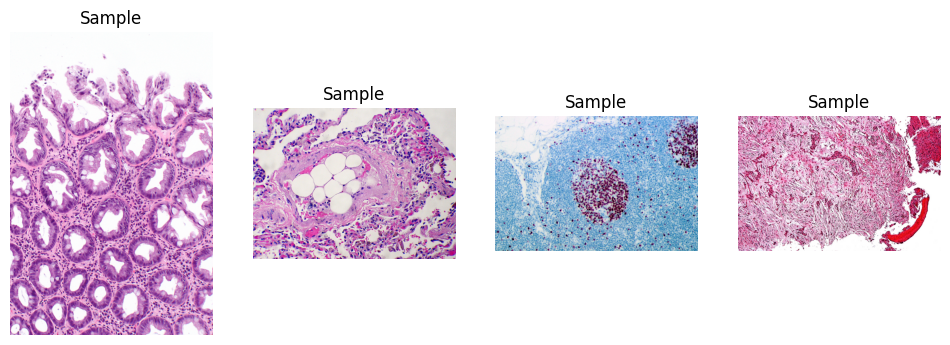

In [ ]:
import matplotlib.pyplot as plt

sample_imgs = jpg_files[:4]

plt.figure(figsize=(12,6))

for i, img_path in enumerate(sample_imgs):
    img = Image.open(img_path)
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title("Sample")
    plt.axis("off")

plt.show()

### Check Dataset Location and Image Files

In [ ]:
import os
print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

Current folder: /content
Files here: ['.config', 'drive', 'nu_data', 'sample_data']


In [ ]:
import glob

DATASET_PATH = "nu_data"   # change if different

jpg_files = glob.glob(f"{DATASET_PATH}/**/*.jpg", recursive=True)
png_files = glob.glob(f"{DATASET_PATH}/**/*.png", recursive=True)

print("JPG count:", len(jpg_files))
print("PNG count:", len(png_files))

JPG count: 8420
PNG count: 1


In [ ]:
print("jpg_files defined?", "jpg_files" in globals())

jpg_files defined? True


### Histogram Analysis of Segmented Object Areas

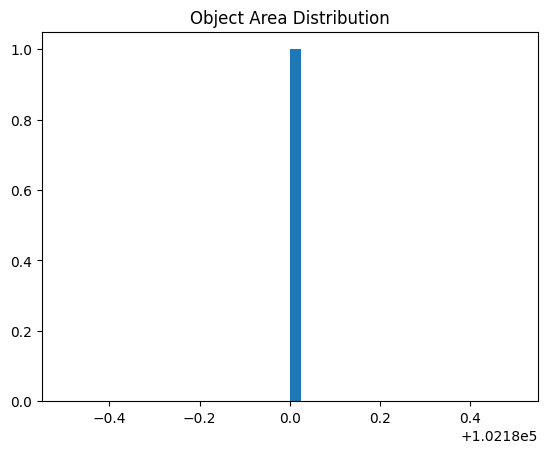

In [ ]:
import cv2

areas = []

for m in mask_files[:100]:
    mask = cv2.imread(m, 0)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for c in contours:
        area = cv2.contourArea(c)
        areas.append(area)

plt.hist(areas, bins=40)
plt.title("Object Area Distribution")
plt.show()

### Train-Test Dataset Distribution Check

In [ ]:
print("Train images:", len(glob.glob("nu_data/stage_1_train/*.jpg")))
print("Test images:", len(glob.glob("nu_data/stage_1_test/*.jpg")))

Train images: 664
Test images: 65
